In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Dataset read-in and details

In [2]:
df = pd.read_csv('./data/telco_customer_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Feature Relationships

### What percentage of customers churned?

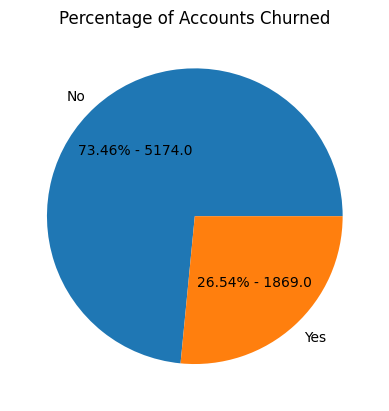

In [8]:
churned_values = df["Churn"].value_counts()
labels = df["Churn"].unique()
total = len(df["Churn"])

def get_autopct(values):
    def make_autopct(val):
        a =  np.round(val*total/100, 0)
        return "{:.2f}% - {}".format(val, a)
    return make_autopct
        

plt.pie(data=df, x=churned_values, labels=labels, autopct=get_autopct(churned_values))
plt.title("Percentage of Accounts Churned")
plt.show()

### Which features are most predictive of whether a customer churns?

In [9]:
# Need binary churned values
df_copy = df.copy()
binary_mappings = {
    "gender":{"Male":0, "Female":1},
    "Partner":{"No":0, "Yes":1},
    "Dependents":{"No":0, "Yes":1},
    "PhoneService":{"No":0, "Yes":1},
    "PaperlessBilling":{"No":0, "Yes":1},
    "Churn":{"No":0, "Yes":1},
}
for feature, val in binary_mappings.items():
    df_copy[feature] = df_copy[feature].map(val)

df_copy.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,0,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,0,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,0,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,1,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [10]:
df_copy[['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']].corr()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,PaperlessBilling,Churn
gender,1.000000,0.001874,0.001808,-0.010517,0.006488,0.011754,0.008612
SeniorCitizen,0.001874,1.000000,0.016479,-0.211185,0.008576,0.156530,0.150889
Partner,0.001808,0.016479,1.000000,0.452676,0.017706,-0.014877,-0.150448
Dependents,-0.010517,-0.211185,0.452676,1.000000,-0.001762,-0.111377,-0.164221
PhoneService,0.006488,0.008576,0.017706,-0.001762,1.000000,0.016505,0.011942
PaperlessBilling,0.011754,0.156530,-0.014877,-0.111377,0.016505,1.000000,0.191825
Churn,0.008612,0.150889,-0.150448,-0.164221,0.011942,0.191825,1.000000


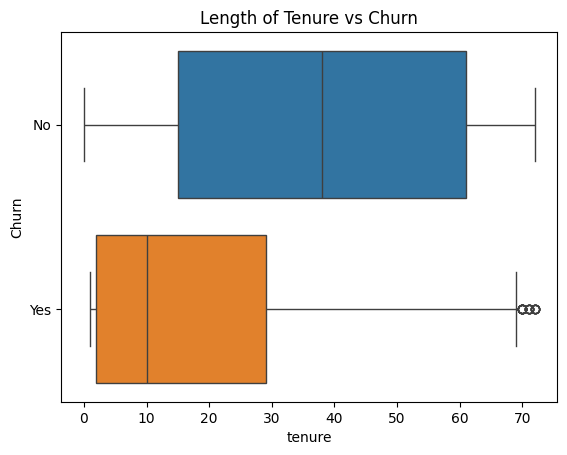

In [11]:
sns.boxplot(data=df, x='tenure', y = 'Churn', hue='Churn')
plt.title("Length of Tenure vs Churn")
plt.show()

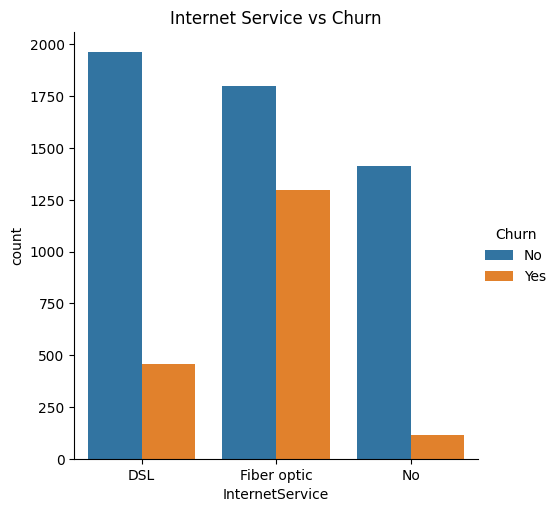

In [12]:
sns.catplot(kind='count', data=df,  x='InternetService', hue='Churn')
plt.title("Internet Service vs Churn")
plt.show()

Text(0.5, 1.0, 'Gender vs Churn')

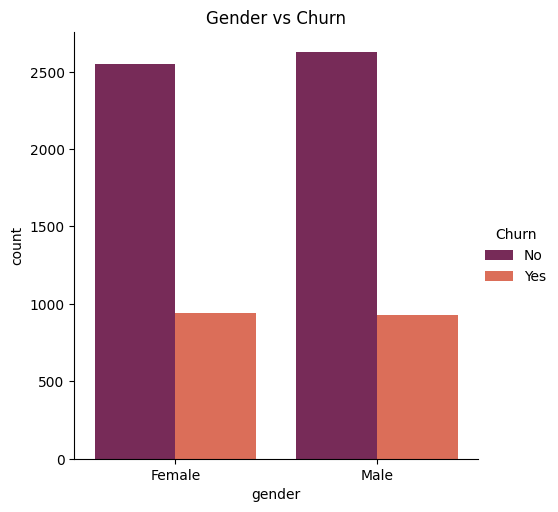

In [34]:
sns.catplot(kind='count', data=df, x='gender', hue='Churn', palette='rocket')
plt.title('Gender vs Churn')

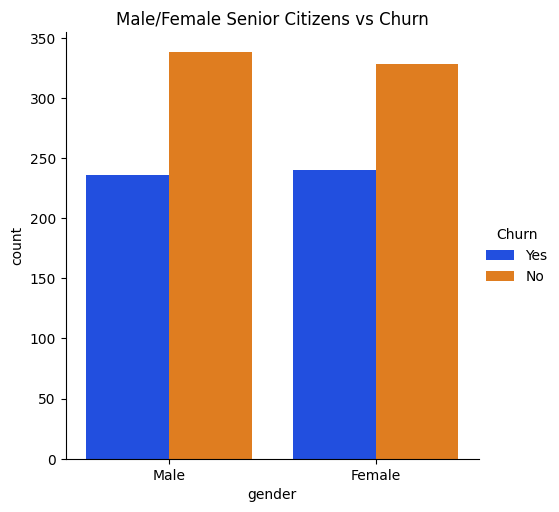

In [33]:
is_senior = df[df['SeniorCitizen'] == 1]
sns.catplot(kind='count', data=is_senior, x='gender', hue='Churn', palette='bright')
plt.title('Male/Female Senior Citizens vs Churn')
plt.show()

## Monthly and Total Charges Affect Churn?

In [45]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
sns.re

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object